# Advanced Statistics and Hypothesis Testing

## What is a Hypothesis?
- It's a statement that proposes a possible explanation for an observed phenomenon or relationship in the data, which data scientistis or statisticians can evaluate through investigation (EDA) or hypothesis testing.
- Hypothesis components:
  - Independent Variable (IV): the one you analyze, improve, or categorize in the DS pipeline.
  - Dependent Variable (DV): the one you **measure** and depends on IV.
  - Examples:
    - Students who study with flashcards score higher on exams than those who don't.
      - IV: Study method (flashcards)
      - DV: Exam score
    - The performance of the vane rotation in wind mills increases with the wind speed
      - IV: Wind speed
      - DV: Vane rotation
    - The higher the square footage, the higher the house price
    - Taking a new drug lowers blood pressure compared to placebo.
      - IV: Drug treatment (new drug vs placebo)
      - DV: Blood pressure level



## What is Hypothesis Testing?
- It's a statistical method used to decide, based on sample data, whether there's enough evidence to support or reject a claim (hypothesis) about a population.
- Basically: "Does the data agree with my claim?" OR "is the difference just a random chance?"
- Hypothesis testing success criteria:
  1. Transparent data collection and method: the sample should be a good representative of the population.
  2. Clear hypothesis: clearly state its components and structure
    - Null and Alternative Hypotheses
    - Independent and dependent variables
  3. Consistency and reproducibility: if we take another sample from the same population and settings, we get the same hypothesis outcome.

### Hypothesis Testing Error Types
- In the outcome of a hypothesis we have correct and incorrect (errors) results.
- Here False/Negative/0 mean the same thing (same for True/Positive/1)
- For errors we have 2 types:
    - **Type I Error** = False Alarm
        - Happens when you **reject the Null Hypothesis** even though it's **actually true**
        - Basically, you detect an effect or difference when none really exists
        - Example: A medical test falsely says a health person has a disease (**False Positive**)
    - **Type II Error** = Missed Detection
        - Happens when you **fail to reject the Null Hypothesis** even though it's **actually false**
        - Basically, you missed detecting an effect or difference when they really exists
        - Example: A medical test falsely says a sick person is health (**False Negative**)

![er](https://www.abtasty.com/wp-content/uploads/type-1-2-errors.png)

### The Process of Hypothesis Testing (Steps)
- Components
  - **Null Hypothesis** ($H_0$)
    - It's a statement of no effect, no difference, or no relationship. It's always the default assumption.
    - We define this to go agains our assumption or observation. The goal is to prove the **null hypothesis** is incorrect to express that our observation is correct.
    - Examples:
      - There's no correlation between age and income
      - There's no difference between two studying methods (flash cards don't cause an impact)
  - **Alternative Hypothesis** ($H_a$)
    - It's a statement that agrees with our hypothesis and we want to prove where there's _statistically significant evidence_.
    - Example:
      - There is a correlation between age and income
      - The flash card studying method is causing an impact (you can specifiy if it's positive or negative - one-tailed hypothesis testing)
  - **Significance Level** (Critical Value) ($\alpha$)
    - It's the probability of rejecting the null hypothesis
    - It controls the _probability of a Type I error (false positive)_
    - In the industry, you define the value before hand and typically you choose between 0.05 and 0.01 (5% vs 1%)
    - Should always be mentioned in the hypothesis (e.g. based on 5% significance level we say....)
    - Significance level must match the **risk tolerance** of the problem. (e.g. lower for medicine, higher for exploratory work)
  - **p-value**
    - Is the probability of a statement from the sample where it's true
    - We compare the p-value to the critical value.
- Steps:
  1. Define the statement of the hypothesis
  2. Set the critical value ($\alpha$)
  3. Frame the Null and Alternative Hypotheses ($H_0$ vs $H_a$) ($H_0$ goes against our statement)
  4. Collect the sample (the sample should be a good representative of the population)
  5. Choose the appropriate statistical test:
    - **t-test** (parametric test - deals with averages)
    - **z-test** (parametric test)
    - **chi-square test**
    - **ANOVA**
    - Other specific tests: MANOVA, Mann-Whitney U, Kruskal-Wallis test
  6. Calculate the $p-value$ using the statistical function of the test from Python and the given sample data
  7. Evaluation based on $p-value$ vs $\alpha$:
    - If $p-value$ > $\alpha$: we **do not reject $H_0$**. In other words, we **accept the null hypothesis**
    - If $p-value$ < $\alpha$: we **do reject $H_0$**. In other words, we **accept the alternative hypothesis**
- The ultimate goal: to determine if there is enough statistical evidence to reject the null hypothesis in favor of the alternative hypothesis. If there isn't sufficient evidence, we fail to reject the null hypothesis. In other words, we do not have enough proof to claim the alternative hypotheiss is true.

![hyp](https://userpage.fu-berlin.de/soga/soga-py/200/2070_hypothesis_tests/img/Generalized_figure_of_two_sided_test.png)

> - The risk tolerance ($\alpha$) is the probability of making a **Type I Error**, which we're willing to take as a risk and reject the null hypothesis.
> - The goal is to have as few as possible numbers in the "false" squares in the confusion matrix - under accepted risk tolerance

### t-test
#### When to use?
- To compare the **means** of 2 groups using 1 numeric measure (parametric test).
- Appropriate when:
  - The population standard deviation is unkown.
  - Sample size is small ($n ≼ 30$). Use it on larger sample if the population SD is unknown.
- Assumptions:
  - Data is approximately normally distributed (especially for a small sample size)
  - Observations are **independent**
  - For independent samples t-test: groups should have approximately equal variances
#### Types:
  - **Independent Sample t-test**:
    - Evaluating the means of **two unrelated groups**
    - Example:
      - The Potassium levels in a  group that eats bananas (group 1) vs a group that doesn't (group 2).
      - Hypothesis:
        - $H_0$: $\mu_1 = \mu_2$ (no change in potassium levels between the groups)
        - $H_a$: $\mu_1 \neq \mu_2$ (means differ -> bananas have an effect)
  - **Paired-Sample t-test** (aka relationship test or dependent t-test):
    - To compare the means of **the same group measured twice** (before & after evaluation)
    - Example:
      - Math scores of students **before vs after** an extra tutoring session:
      - Hypothesis
        - $H_0$: $\mu_{before} = \mu_{after}$ (no change in exam scores)
        - $H_a$: $\mu_{before} \neq \mu_{after}$ (means differ -> extra tutoring session have an effect)
  - **One-Sample t-test**
    - To compare the mean of a sample to a **known or claimed population mean**.
    - Example:
      - Testing if the average IQ in the sample differs from the **published** US average of 109.
      - Hypothesis:
        - $H_0$: $\mu_{s} = \mu_{population}$ (sample and population IQ are the same)
        - $H_a$: $\mu_{s}\neq \mu_{population}$ (sample and population IQ are different)

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as sts

In [ ]:
!unzip /content/stats_exercise_data.zip

Archive:  /content/stats_exercise_data.zip
  inflating: AB_Testing_Website.csv  
  inflating: __MACOSX/._AB_Testing_Website.csv  
  inflating: adultcensusincome.csv   
  inflating: __MACOSX/._adultcensusincome.csv  
  inflating: blood_pressure.csv      
  inflating: __MACOSX/._blood_pressure.csv  
  inflating: Ages.csv                
  inflating: __MACOSX/._Ages.csv     
  inflating: Shopping.csv            
  inflating: __MACOSX/._Shopping.csv  
  inflating: crop_yield_treatment.csv  
  inflating: __MACOSX/._crop_yield_treatment.csv  
  inflating: Mann-Whitney_U_Salaries.csv  
  inflating: __MACOSX/._Mann-Whitney_U_Salaries.csv  


#### Exercise: Independent Sample t-test - (A/B Testing)
Imagine you work for an e-commerce company, and your team is responsible for optimizing the company's website to increase user engagement and, ultimately, sales. The current design of the "Buy Now" button on the website is being tested against a new design to see if it leads to a higher conversion rate (or change in conversion rate).

Data Collection and Evaluation Method - for placebo and having a control group:
1. Randomly select website users broken into group A and B (independent groups)
2. Give group A the old website with the old functionality and group B new website (with new button)
3. Measure the usage score
4. Perform an **independent statistical test** whether there's a difference in teh engagement or not

Hypothesis:
  - $H_0$: $\mu_A = \mu_B$ (no change in usage between the groups)
  - $H_a$: $\mu_A \neq \mu_B$ (means differ -> the new functionality has an effect)

In [ ]:
df = pd.read_csv('/content/AB_Testing_Website.csv')
df.head()

,Group_A,Group_B
0,38,47
1,34,48
2,35,50
3,35,49
4,35,46


In [ ]:
#set the critical value
alpha = 0.05

In [ ]:
# run t-test analysis using the t-test ind function
# calculate the p-value - step
p_val = sts.ttest_ind(df['Group_A'],df['Group_B'])[1] #p-value comes as the second output of the function

p_val

np.float64(8.2568977246166655e-22)

In [ ]:
#evaluation - step 7
if p_val > alpha:
  print('We do not reject the null hypothesis.')
else:
  print('We reject the null hypothesis')

We reject the null hypothesis


> Conclusion: We reject the null hypothesis -> the new button functionality has an effect on usage.

> Note that the p-value for $H_0$ is very low. We can even change $\alpha$ to 0.01 and it will work. (99% confidence to reject the null hypotheiss)

#### One-sided vs Two-sided Tests

What if we want to perform an evaluation with a direction? (i.e. positive or negative impact?
- This is basically called the One-Sided test
- You do not need to split the alpha (half) the function should take care of that
- When you perform the one-sided t-test, you are only considering one direction
- For the `ttest_ind`, we can use `alternative=` attribute

![1s](https://mverbakel.github.io/assets/one_vs_two_sided.png)

To convert this into our object (group B with the new button has better engagement), hypothesis:
- $H_0$: $\mu_B <= \mu_A$ (the new button is performing similar or worse than the old one)
- $H_a$: $\mu_B > \mu_A$ (the new button is performing better)


> We need to make sure we choose `greater` as the alternative value and place Group B first.

In [ ]:
p_val = sts.ttest_ind(df['Group_B'],df['Group_A'], alternative='greater')[1]
p_val

np.float64(4.1284488623083327e-22)

In [ ]:
if p_val > alpha:
  print('We do not reject the null hypothesis.')
else:
  print('We reject the null hypothesis')

We reject the null hypothesis


Conclusion:
- We reject the null hypothesis -> the new button funcitonality is performign better in terms of engagement/usage.
- Note that the value is approximeltly half of the previous p value for double-sided

---

Building a generalized custom function for our evaluation can make our process more efficient:

In [ ]:
def HypoTesting(p_val, alpha=0.05): #giving alpha a defaul value of 5% - can be changed by the user
  if p_val > alpha:
    print('We do not reject the null hypothesis.')
  else:
    print('We reject the null hypothesis')


---

#### Exercise: Paired-Sample t-test
For a particular hospital, it is advertised that its chemotherapy session does not affect the patient's health based on blood pressure (BP). To test the claim, we check if the BPP before the treatment is equivalent to the BP after for **the same patients**. Perform statistical significance analysis at alpha = 5% to evaluate the claim.

- $H_0$: $\mu_{bef} = \mu_{aft}$ (no change in BP levels after the treatment - same group)
- $H_a$: $\mu_{bef} \neq \mu_{aft}$ (means differ -> chemo has effect on BP)

In [ ]:
df = pd.read_csv('/content/blood_pressure.csv')
df.head()

,patient,sex,agegrp,bp_before,bp_after
0,1,Male,30-45,143,153
1,2,Male,30-45,163,170
2,3,Male,30-45,153,168
3,4,Male,30-45,153,142
4,5,Male,30-45,146,141


In [ ]:
p_val = sts.ttest_rel(df['bp_before'], df['bp_after'])[1]

In [ ]:
HypoTesting(p_val)

We reject the null hypothesis


> Conclusion: We reject the null hypothesis -> There's a statically significant impact on blood pressure after the treatment.

#### Exercise: One-Sample t-test
For a particular organization, the average age of the employees was claimed 30 years.
The authorities collected a random sample of 10 employees' age data to check the claim made by the organization.
Construct a hypothesis test to validate the hypothesis at a significance level of 5%.

For $\chi = 30$:
- $H_0$: $\mu_s = \chi $ (there's no difference - the claimed population average still holds)
- $H_a$: $\mu_s \neq \chi $

In [ ]:
df = pd.read_csv('/content/Ages.csv')
df.head()

,ages
0,34
1,45
2,65
3,78
4,32


In [ ]:
p_val = sts.ttest_1samp(df, popmean=30)[1]

In [ ]:
HypoTesting(p_val)

We reject the null hypothesis


> Conclusion: we reject the null hypothesis -> the claim of average employee age = 30 is no longer true.

### z-test

#### When to use?
1. Large sample size ($n >= 30$)
2. The **population standard deviation is known**
3. Similar to t-test, we also have 3 main types:
  - Independent z-test
  - Paired sample z-test
  - One-sample z-test

#### Exercise
A school principal claims that students in his school are more intelligent than those in other schools. To test this claim, a random sample of 50 students was taken, yielding an average IQ score of 110. The known population mean IQ is 100 with a standard deviation of 15. Determine, at the 5% significance level, whether the principal’s claim is supported.

**Solution**
1. Define the Hypothesis Statements:
  - $H_0: \mu_s = \chi$ (the sample's average IQ is the same as the population - we disagree with the principal)
  - $H_a: \mu_s \neq \chi$ (the sample's average IQ is not the same as the population - we partially agree with the principal)
2. Extract the information (givens) from the problem statement

In [ ]:
#evaluation info
alpha = 0.05

#population info
pop_mean = 100
pop_sd = 15

#sample info
sam_mean = 110
sam_size = 50

- Since we know the SD of the population and the size > 50, we can sue the z-test
- We don't have access to the actual data. However, we do have access to its parameters and statistics.
- Thefore, we can use them to "synthetically" generat (mimic) the original data for student's IQ results - **assuming it follows a normal distrinbution**
- In order to generate the data, we're missing the sample standard deviation. So, we need to derive it using the following formula:

![sd](https://uedufy.com/wp-content/uploads/2022/03/image-3.png)

1. Calculate the Sd of the sample

In [ ]:
import math

sam_sd = pop_sd/math.sqrt(sam_size)
print('Sample Standard Deviation:', sam_sd)

Sample Standard Deviation: 2.1213203435596424


2. Generate the sample data. Using NumPy's `random.normal()` function and the statistics of the sample

In [ ]:
student_sample = np.random.normal(loc=sam_mean, scale=sam_sd, size=sam_size)
student_sample

array([113.84907439, 110.01713511, 112.0056443 , 111.91536665,
       110.67463384, 110.8705657 , 109.31108271, 108.76419775,
       111.82688002, 104.42704202, 110.8994    , 105.94961359,
       110.5031284 , 115.91608531, 106.74047457, 106.21245494,
       114.18285441, 109.00875916, 109.98892428, 111.47789885,
       107.60365779, 110.50799826, 109.42509284, 110.33723544,
       110.04686962, 111.99633073, 109.14939585, 110.82358865,
       113.96231329, 110.0628931 , 108.93576989, 109.91725642,
       107.97954565, 113.84004916, 111.93344294, 107.50339955,
       111.93635201, 113.06286931, 110.46353643, 111.02174356,
       109.16860347, 111.20118331, 109.26029989, 108.83512383,
       108.70133486, 114.2642112 , 106.8985118 , 107.92074305,
       111.24942172, 107.28483585])

In [ ]:
#quick qa check
len(student_sample)

50

In [ ]:
np.mean(student_sample)

np.float64(110.19669650890988)

`pip install statsmodels`

In [ ]:
from statsmodels.stats.weightstats import ztest

In [ ]:
p_val = ztest(student_sample, value=pop_mean)[1]

In [ ]:
HypoTesting(p_val,alpha)

We reject the null hypothesis


> Conclusion: we reject the null hypotheiss. The principal's claim might be true. We need one-tail test to confirm if the IQ greater.

Now, the hypothesis becomes:
- $H_0: \mu_s <= \chi$ (the sample's average IQ is the same as the population or less - we disagree with the principal)
- $H_a: \mu_s > \chi$ (the sample's average IQ is greater than  the population - we agree with the principal)

In [ ]:
p_val = ztest(student_sample, value=pop_mean, alternative='larger')[1]
HypoTesting(p_val,alpha)

We reject the null hypothesis


> **Final Conclusion:** We reject the null hypothesis. Thefore, the principal's claim is true (assuming the sample has a normal distribution)

---

Previous statistical tests evaluate 1 or 2 **numerical** groups. To evaluate categorical, we need to use a different type of tests called Chi-square Test

---

### Chi-square Distribution and Test

![chi](https://www.easysevens.com/wp-content/uploads/2024/01/Chi-Squared-Distribution.png)

#### About
- $\chi^2$ is a continuous probability distribution (normal distribution is also continuous)
- It's used for hypotheiss testing and contruction of confidence intervals
- Characteristics:
  - Non-negative values
  - Degrees of Freedom (DoF): defines the shape of the chi-square
  - Positively (right) skewed.
- Chi-square test is used to determine whether there is a statistically significant association between categorical variables.


#### Steps
Similar to a standard hypothesis testing, but with additional steps.

1. Define the statement of the hypothesis
2. Set the critical value ($\alpha$)
3. Frame the Null and Alternative Hypotheses ($H_0$ vs $H_a$) ($H_0$ goes against our statement)
  - $H_0$: There is no association between the two variables (they are independent)
  - $H_a$: There is an association between the two variables (they are dependent)
4. Collect the sample (the sample should be a good representative of the population)
5. Build the contingency table
6. Calculate the $p-value$ using the `chi2` function in Python on the contingency table
7. Evaluation based on $p-value$ vs $\alpha$:
  - If $p-value$ > $\alpha$: we **do not reject $H_0$**. In other words, we **accept the null hypothesis**
  - If $p-value$ < $\alpha$: we **do reject $H_0$**. In other words, we **accept the alternative hypothesis**

#### Exercise
We have a survey for purchased car color based on gender. We want to find out if there's an associate between gender and favorite car color.

Solution:
- $H_0$: There is no association between car color and gender
- $H_a$: There is an association between car color and gender

In [ ]:
df = pd.read_csv('/content/Shopping.csv')
df.sample(20)

,Gender,Car Color
91,F,Pink
50,F,Pink
0,M,Black
10,M,Black
22,M,Black
86,F,White
35,M,Silver
66,F,White
75,F,Silver
81,F,Pink


In [ ]:
# check if the gender category is balanced
df['Gender'].value_counts()

,count
Gender,
F,55
M,49


In [ ]:
df['Car Color'].value_counts()

,count
Car Color,
Black,31
Silver,24
Pink,24
White,16
Red,9


In [ ]:
alpha =0.05

In [ ]:
cont_table = pd.crosstab(df['Gender'], df['Car Color'])
cont_table

Car Color,Black,Pink,Red,Silver,White
Gender,,,,,
F,9,22,2,8,14
M,22,2,7,16,2


- Pink is the most popular color for F and Black is for M
- There is a noticable variation betwene M and F

<Axes: xlabel='Car Color', ylabel='Gender'>

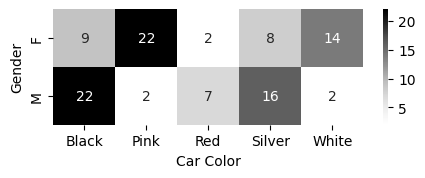

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,1.5))
sns.heatmap(cont_table, annot=True, cmap='Grays')

In [ ]:
p_val = sts.chi2_contingency(cont_table)[1]

In [ ]:
HypoTesting(p_val)

We reject the null hypothesis


> **Conclusion**: We reject the null hypothesis -> There's a statistical evidence that there's an association/relationship between car color and gender.

(Optional) along with the p-value, the `chi2_contingency` gives us a contingency table that **satisfies the null hypothesis**. It's called the **Expected Frequency** - sometimes can be used to double check the results.

In [ ]:
exp_freq = sts.chi2_contingency(cont_table)[3] #index 3 has the cont table for null hypo
exp_freq

array([[16.39423077, 12.69230769,  4.75961538, 12.69230769,  8.46153846],
       [14.60576923, 11.30769231,  4.24038462, 11.30769231,  7.53846154]])

In [ ]:
# the best method to read it, is to convert into a dataframe with labels
exp_freq_df = pd.DataFrame(data=exp_freq
                           ,index=df['Gender'].unique() #gender categories
                           ,columns=df['Car Color'].unique() #color categories
                           )
exp_freq_df

,Black,Silver,Red,White,Pink
M,16.394231,12.692308,4.759615,12.692308,8.461538
F,14.605769,11.307692,4.240385,11.307692,7.538462


### ANOVA
#### About
- **AN**alysis **o**f **VA**riance
- It assesses whether there are **significant differences between the means of three or more groups**.
- It's like an extension of the t-test and z-test (for 2 groups only)
- Types:
  - **One-way ANOVA** deals with one factor/measure for multiple groups. e.g. student IQ (factor/measurement) for 3 or more different classes
  - **Two-way ANOVA** deals with two factors/measures for multiple groups. e.g. student IQ and Age (factors/measurements) for 3 or more different classes
  - **MANOVA** deals with multiple factors/measures (more than 2) for multiple groups.

#### Steps
Similar to a standard hypothesis testing, but with additional steps.
1. Define the statement of the hypothesis
2. Set the critical value ($\alpha$)
3. Frame the Null and Alternative Hypotheses ($H_0$ vs $H_a$) ($H_0$ goes against our statement)
  - $H_0$: There is no statistically significant difference between all groups.
  - $H_a$: There is at least one group with a statistically significant difference compared to others.
4. Collect the sample (the sample should be a good representative of the population)
5. Choose the appropriate statistical test (ANOVA, Two-way ANOVA, or MANOVA)
6. Calculate the $p-value$ using the statistical function of the test from Python and the given sample data
7. Evaluation based on $p-value$ vs $\alpha$:
  - If $p-value$ > $\alpha$: we **do not reject $H_0$**. In other words, we **accept the null hypothesis**
  - If $p-value$ < $\alpha$: we **do reject $H_0$**. In other words, we **accept the alternative hypothesis**

#### Exercise
Suppose you are a researcher conducting an agricultural study to compare the yield of three different fertilizer treatments (Treatment A, Treatment B, and Treatment C) on a specific type of crop. You want to determine if there are significant differences in crop yields among the treatments.

Solution:
- $H_0$: There is no statistically significant difference between all fertilizer treatments.
- $H_a$: There is at least one fertilizer treatment with a statistically significant difference compared to others.

In [ ]:
df = pd.read_csv('/content/crop_yield_treatment.csv')
df.head()

,Treatment_A,Treatment_B,Treatment_C
0,50,56,49
1,54,47,57
2,57,55,46
3,49,41,40
4,46,56,54


In [ ]:
p_val = sts.f_oneway(df['Treatment_A'], df['Treatment_B'], df['Treatment_C'])[1]

In [ ]:
HypoTesting(p_val)

We do not reject the null hypothesis.


> **Conclusion**: We do not reject the null hypothesis. There is no statistically significant difference between all fertilizer treatments. In other words, all fertelizer treatments yield the same output.

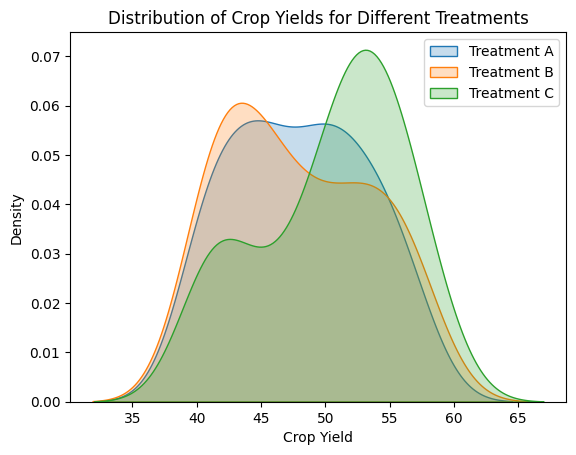

In [ ]:
sns.kdeplot(df['Treatment_A'], fill=True, label='Treatment A')
sns.kdeplot(df['Treatment_B'], fill=True, label='Treatment B')
sns.kdeplot(df['Treatment_C'], fill=True, label='Treatment C')
plt.title('Distribution of Crop Yields for Different Treatments')
plt.xlabel('Crop Yield')
plt.ylabel('Density')
plt.legend()

### Mann-Whitney U Test
- There's a weakness with using z-test adn t-test; if the data is not approximately normally distributed
- In a scenario where the distribution is inconsistent and far from the bell curve, we can use a **non-parameteric** statistical evaluation, such as Mann-Whitney U test.
- Non-parametric evaluation means:
  - You cannot rely on statistical measures like mean or median to interpret the data.
  - The distribution does not follow a normal distribution - resemble a bell curve.
- Same hypothesis testing process. The component:
  - $H_0$: there's no difference between group A and B
  - $H_a$: there's a difference between group A and B

### Exercise
Evaluate the salaries of post-graduate students from 2 different universities and check if the are differnt from each other based on 5% critical value.

In [ ]:
df = pd.read_csv('/content/Mann-Whitney_U_Salaries.csv')
df.head()

,UnivOfDallas,ArizonaStateUniv
0,71555,73589
1,67887,83621
2,84334,74681
3,70133,83873
4,89304,72350


array([[<Axes: title={'center': 'UnivOfDallas'}>,
        <Axes: title={'center': 'ArizonaStateUniv'}>]], dtype=object)

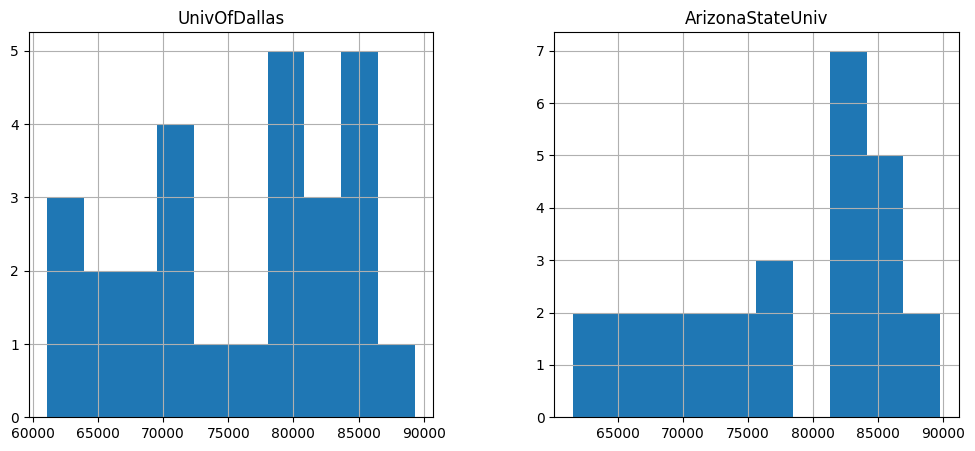

In [ ]:
df.hist(figsize=(12,5))

Since the distribution is not normal/Gaussian, we cannot rely on parametric tests. Therefore, we can use the Mann-Whitney U test.

In [ ]:
p_val = sts.mannwhitneyu(df['UnivOfDallas'],df['ArizonaStateUniv'])[1]

In [ ]:
HypoTesting(p_val)

We do not reject the null hypothesis.


> **Conclusion**: Wedo not reject the null hypothesis -> there's no statisticall significant difference between the 2 salary data of the universities.